<a href="https://colab.research.google.com/github/Mradul2k04/Machine_Learning/blob/Project/02_Loan_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [228]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [229]:
#Read and load the Dataset
df=pd.read_csv("/content/hdfc_loan_dataset_full_enriched - hdfc_loan_dataset_full_enriched.csv")

In [230]:
#Showing all the columns in the dataset
df

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,HDFC100996,HDFC Bank,Simran Kaur,Male,Yes,1,Graduate,Salaried,44713,0,...,10.965,Neutral,Sikh,Tamil Nadu,Coimbatore,6635,3.830000e+11,9350952889,simran.kaur@example.in,Medical Representative
996,HDFC100997,HDFC Bank,Krishna Mehta,Male,No,2,Graduate,Salaried,70886,0,...,3.268,Negative,Hindu,Kerala,Trivandrum,217843,7.040000e+11,9176504718,krishna.mehta@example.in,Customer Support Executive
997,HDFC100998,HDFC Bank,Rohan Verma,Female,No,1,Graduate,Salaried,24392,11337,...,0.703,Positive,Hindu,Delhi,New Delhi,89211,9.954289e+10,9966866798,rohan.verma@example.in,Driver
998,HDFC100999,HDFC Bank,Ananya Joshi,Female,No,2,Graduate,Salaried,64803,94136,...,0.377,Negative,Hindu,Gujarat,Ahmedabad,532976,6.170000e+11,9103847156,ananya.joshi@example.in,Electrician


In [231]:
#Selecting the Columns in which we have to perform the operations
df_columns=df[["Loan_Amount","Loan_Term_Months","Applicant_Income","Coapplicant_Income","Existing_EMIs"]].copy()
df_columns.reset_index()

,index,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs
0,0,8031545,360,56976,0,5610
1,1,899361,240,1856,0,9166
2,2,2387748,60,64553,0,0
3,3,658856,12,88450,0,26613
4,4,198671,36,9539,0,0
...,...,...,...,...,...,...
995,995,5883603,360,44713,0,5165
996,996,2780228,300,70886,0,20102
997,997,301249,24,24392,11337,34514
998,998,719891,48,64803,94136,34000


In [232]:
#Showing the Selected Columns
df_columns

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs
0,8031545,360,56976,0,5610
1,899361,240,1856,0,9166
2,2387748,60,64553,0,0
3,658856,12,88450,0,26613
4,198671,36,9539,0,0
...,...,...,...,...,...
995,5883603,360,44713,0,5165
996,2780228,300,70886,0,20102
997,301249,24,24392,11337,34514
998,719891,48,64803,94136,34000


In [233]:
#Adding the new Colums in the dataframe for Monthly Income
df_columns["Monthly Income"]=df_columns["Applicant_Income"]+df_columns["Coapplicant_Income"]
df_columns

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income
0,8031545,360,56976,0,5610,56976
1,899361,240,1856,0,9166,1856
2,2387748,60,64553,0,0,64553
3,658856,12,88450,0,26613,88450
4,198671,36,9539,0,0,9539
...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713
996,2780228,300,70886,0,20102,70886
997,301249,24,24392,11337,34514,35729
998,719891,48,64803,94136,34000,158939


In [234]:
#CALCULATE THE INTEREST THAT BANK TAKE PER YEAR ON LOAN AMOUNT
std_interest_rate=12
df_columns["Annual_Interest"] = (df_columns["Loan_Amount"]*std_interest_rate*1)/100
df_columns.head()

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest
0,8031545,360,56976,0,5610,56976,963785.40
1,899361,240,1856,0,9166,1856,107923.32
2,2387748,60,64553,0,0,64553,286529.76
3,658856,12,88450,0,26613,88450,79062.72
4,198671,36,9539,0,0,9539,23840.52


In [235]:
#Calculate the Bank Revenue that BANK COLLECT PER YEAR
Bank_Annual_revenue = df_columns["Annual_Interest"].sum()
print(f"Annual Revenue Collected By the Bank per Year: ",Bank_Annual_revenue)

Annual Revenue Collected By the Bank per Year:  266005548.12


In [236]:
#Calculate the utility function
df_columns["U"]=df_columns["Annual_Interest"]-(df["Existing_EMIs"]*12)
df_columns

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U
0,8031545,360,56976,0,5610,56976,963785.40,896465.40
1,899361,240,1856,0,9166,1856,107923.32,-2068.68
2,2387748,60,64553,0,0,64553,286529.76,286529.76
3,658856,12,88450,0,26613,88450,79062.72,-240293.28
4,198671,36,9539,0,0,9539,23840.52,23840.52
...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36
996,2780228,300,70886,0,20102,70886,333627.36,92403.36
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08


In [237]:
#The goal is to locate the optimal loan range..
df_columns["dU"]=df_columns["U"].diff()
df_columns["dL"]=df_columns["Loan_Amount"].diff()
df_columns['dU_dL']=df_columns["dU"]/df_columns["dL"]
df_columns

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973
...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733


# NumPy Concepts
Use:

np.sum()

np.square()

np.argmax()

np.argmin()


In [238]:
# Calculate the sum of Existing EMi Collected by bank
total_emi_collected = np.sum(df_columns["Existing_EMIs"])
print(f"Total EMI Collected By the Bank: ",total_emi_collected)

Total EMI Collected By the Bank:  18173390


In [239]:
# To calculate the Maximum loan amount|
max_loan_amount = np.argmax(df_columns["Loan_Amount"])
print(f"Maximum Loan Amount Index: ",max_loan_amount)

Maximum Loan Amount Index:  874


In [240]:
# To calculate the Minimum loan amount|
min_loan_amount = np.argmin(df_columns["Loan_Amount"])
print(f"Minimum Loan Amount Index: ",min_loan_amount)

Minimum Loan Amount Index:  63


# Task 1

Create an affordability metric.

Example:

Affordability Ratio = Monthly Obligations / Monthly Income



In [241]:
df_columns["Affordability_Ratio"]=((df_columns["Annual_Interest"]/12)+df_columns["Existing_EMIs"])/df_columns["Monthly Income"]
df_columns


,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL,Affordability_Ratio
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272
...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212


# Task 2
Create revenue estimates for different loan ranges.


In [242]:
loan_bins=[0,500000,1000000,1500000,2500000,np.inf]
loan_lables=["low","basic","medium","high","very-high"]
df_columns["Loan_Range"]=pd.cut(df_columns["Loan_Amount"],bins=loan_bins,labels=loan_lables)
df_columns

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very-high
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,basic
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,high
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,basic
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very-high
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very-high
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,low
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,basic


In [243]:
revenue_by_loan_range=df_columns.groupby("Loan_Range",observed=True)["Annual_Interest"].mean()
revenue_by_loan_range

,Annual_Interest
Loan_Range,
low,32023.623324
basic,85078.276829
medium,146340.720000
high,227067.635294
very-high,671466.496471


# Task 3
Create a utility function balancing:

Revenue

Affordability

Risk


In [244]:
#Make the new Dataframe for finite values
clean_df=df_columns[np.isfinite(df_columns["Affordability_Ratio"])].copy()
clean_df

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very-high
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,basic
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,high
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,basic
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very-high
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very-high
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,low
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,basic


In [245]:
#Normalise
clean_df["norm_revenue"]=(clean_df["Annual_Interest"]-clean_df["Annual_Interest"].min())/(clean_df["Annual_Interest"].max()-clean_df["Annual_Interest"].min())
clean_df["norm_affordability"]=(clean_df["Affordability_Ratio"]-clean_df["Affordability_Ratio"].min())/(clean_df["Affordability_Ratio"].max()-clean_df["Affordability_Ratio"].min())
clean_df

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range,norm_revenue,norm_affordability
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very-high,0.582320,0.010923
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,basic,0.065086,0.070906
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,high,0.173026,0.002673
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,basic,0.047644,0.002713
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,low,0.014271,0.001502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very-high,0.426549,0.010367
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very-high,0.201489,0.004890
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,low,0.021710,0.007605
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,basic,0.052071,0.001871


In [246]:
# Utility = Revenue benefit-Affordability Ratio
clean_df["Utility"]=clean_df["norm_revenue"]-clean_df["norm_affordability"]
clean_df

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range,norm_revenue,norm_affordability,Utility
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very-high,0.582320,0.010923,0.571398
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,basic,0.065086,0.070906,-0.005820
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,high,0.173026,0.002673,0.170352
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,basic,0.047644,0.002713,0.044931
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,low,0.014271,0.001502,0.012769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very-high,0.426549,0.010367,0.416182
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very-high,0.201489,0.004890,0.196598
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,low,0.021710,0.007605,0.014105
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,basic,0.052071,0.001871,0.050199


#Task 4
Compute first derivatives using numerical methods.


In [247]:
#first derivatives using numerical methods.
clean_df["dU"]=clean_df["U"].diff()
clean_df["dL"]=clean_df["Loan_Amount"].diff()
clean_df["dU_dL_gradienr"]=np.gradient(clean_df["dU"],clean_df["dL"])
clean_df

,Loan_Amount,Loan_Term_Months,Applicant_Income,Coapplicant_Income,Existing_EMIs,Monthly Income,Annual_Interest,U,dU,dL,dU_dL,Affordability_Ratio,Loan_Range,norm_revenue,norm_affordability,Utility,dU_dL_gradienr
0,8031545,360,56976,0,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very-high,0.582320,0.010923,0.571398,NaN
1,899361,240,1856,0,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,basic,0.065086,0.070906,-0.005820,NaN
2,2387748,60,64553,0,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,high,0.173026,0.002673,0.170352,0.322366
3,658856,12,88450,0,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,basic,0.047644,0.002713,0.044931,0.864331
4,198671,36,9539,0,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,low,0.014271,0.001502,0.012769,-0.139017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5883603,360,44713,0,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very-high,0.426549,0.010367,0.416182,-0.150422
996,2780228,300,70886,0,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very-high,0.201489,0.004890,0.196598,0.129478
997,301249,24,24392,11337,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,low,0.021710,0.007605,0.014105,0.139260
998,719891,48,64803,94136,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,basic,0.052071,0.001871,0.050199,-0.240339


### Visualizations


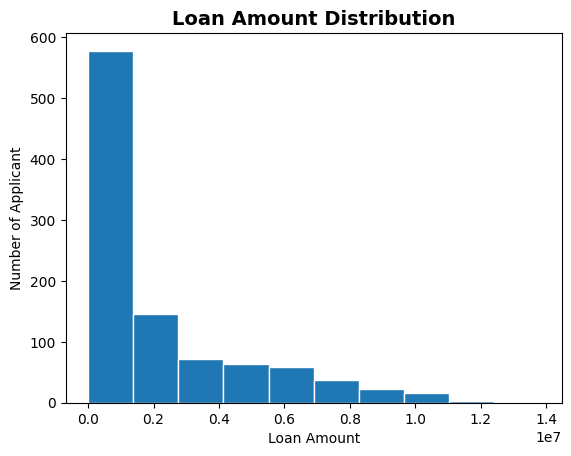

In [248]:
#Visual 1
#Loan Amount Distribution
plt.hist(df_columns["Loan_Amount"],bins=10,edgecolor='white')
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicant")
plt.title("Loan Amount Distribution",fontsize=14, fontweight="bold")
plt.show()



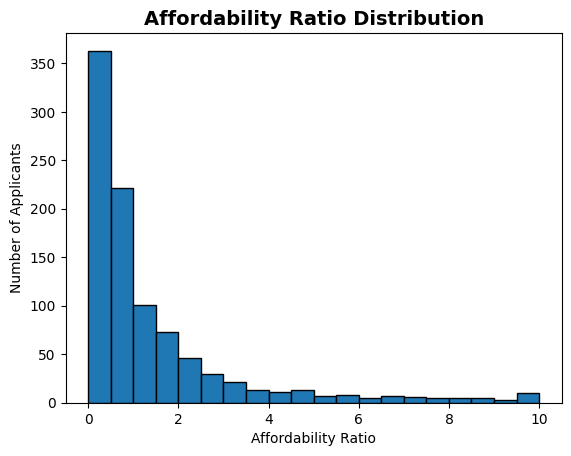

In [249]:
#Visual 2
#Affordability Ratio Distribution
mask = np.isfinite(df_columns["Affordability_Ratio"]) & (df_columns["Affordability_Ratio"] <=10.0)
filtered_ratio = df_columns["Affordability_Ratio"][mask]
plt.hist(filtered_ratio, bins=20, edgecolor='black')
plt.xlabel("Affordability Ratio")
plt.ylabel("Number of Applicants")
plt.title("Affordability Ratio Distribution", fontsize=14, fontweight="bold")
plt.show()


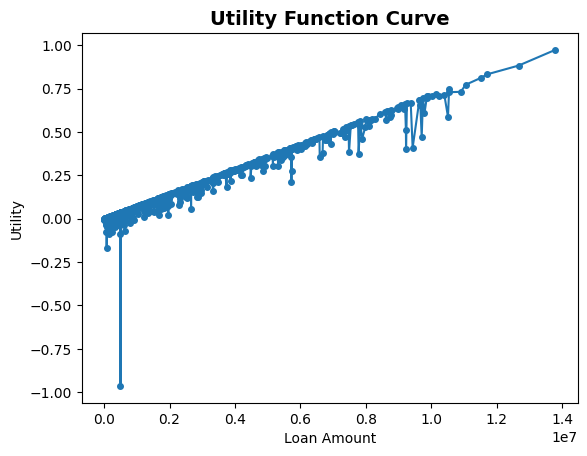

In [250]:
#Visual 3
#Utility Function Curve
df_sorted = clean_df.sort_values(by="Loan_Amount")
plt.plot(df_sorted["Loan_Amount"], df_sorted["Utility"], marker='o', markersize=4)
plt.xlabel("Loan Amount")
plt.ylabel("Utility")
plt.title("Utility Function Curve", fontsize=14, fontweight="bold")
plt.show()
